# Analyse exploratoire : dataset Open Agenda

Source : dataset public [`evenements-publics-openagenda`](https://public.opendatasoft.com/explore/dataset/evenements-publics-openagenda/) sur 
OpenDataSoft.

Interrogé avec l'[Explore API v2.1](https://help.opendatasoft.com/apis/ods-explore-v2/explore_v2.1.html) (filtres en langage ODSQL).

## 0. Initialisation

#### Import

In [84]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
import missingno as msno

#### Constantes

In [85]:
# Chemins
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

# API
API_URL = "https://public.opendatasoft.com/api/explore/v2.1/catalog/datasets/evenements-publics-openagenda"

## 1. Exploration du dataset

#### Fonctions support

In [86]:
def query(where=None, **params):
    """Appelle l'endpoint /records avec un filtre ODSQL."""
    if where:
        params["where"] = where
    response = requests.get(f"{API_URL}/records", params=params, timeout=30)
    response.raise_for_status()
    return response.json()

def count(where=None):
    """Nombre d'événements correspondant au filtre."""
    return query(where, limit=0)["total_count"]

def group(fields, where=None, limit=15):
    """Nombre d'événements par valeur de champ, du plus fréquent au moins fréquent."""
    results = query(where, select=f"{fields}, count(*) as n", group_by=fields, order_by="n desc", limit=limit)
    return pd.DataFrame(results["results"])

#### Nombre d'événements et champs disponibles

Comme demandé on se restreint aux événements de moins d'un an.

In [87]:
# Nombre d'événements disponibles
print(f"{count():,} événements recensés")

# Filtre temporel
RECENT = "lastdate_end >= date'2025-09-01'"
print(f"dont {count(RECENT):,} événements récents.\n")

# Recuperation de la structure des champs
print("Champs existants :")
for f in requests.get(API_URL).json()["fields"]:
    print(f" - {f["name"]}")

1,254,053 événements recensés
dont 339,145 événements récents.

Champs existants :
 - uid
 - slug
 - canonicalurl
 - title_fr
 - description_fr
 - longdescription_fr
 - conditions_fr
 - keywords_fr
 - image
 - imagecredits
 - thumbnail
 - originalimage
 - updatedat
 - daterange_fr
 - firstdate_begin
 - firstdate_end
 - lastdate_begin
 - lastdate_end
 - timings
 - accessibility
 - accessibility_label_fr
 - location_uid
 - location_coordinates
 - location_name
 - location_address
 - location_district
 - location_insee
 - location_postalcode
 - location_city
 - location_department
 - location_region
 - location_countrycode
 - location_image
 - location_imagecredits
 - location_phone
 - location_website
 - location_links
 - location_tags
 - location_description_fr
 - location_access_fr
 - attendancemode
 - onlineaccesslink
 - status
 - age_min
 - age_max
 - originagenda_title
 - originagenda_uid
 - contributor_email
 - contributor_contactnumber
 - contributor_contactname
 - contributor_con

340 k événement est trop important pour un premier POC, on cherche donc une zone géographique plus raisonnable.

## 2. Choix d'une zone géographique

On évalue ensuite la zone géographique à étudier pour obtenir un dataset de taille acceptable.

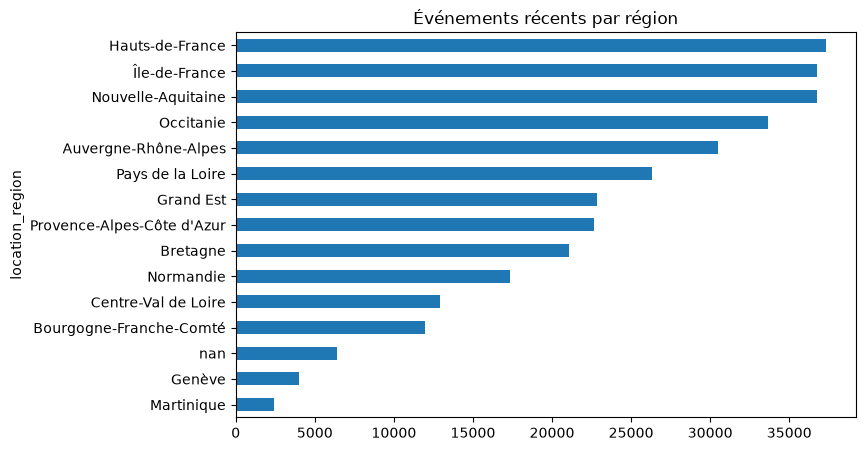

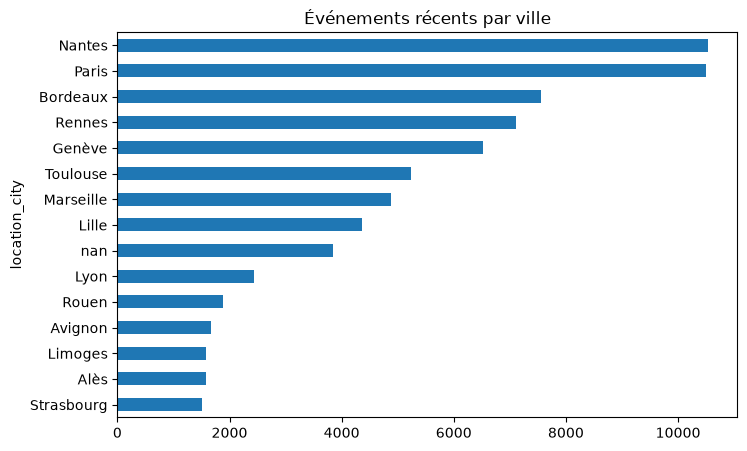

In [88]:
# Par région
regions = group("location_region", RECENT)
regions.set_index("location_region")["n"].sort_values().plot.barh(figsize=(8, 5), title="Événements récents par région")
plt.show()

# Par ville
cities = group("location_city", RECENT)
cities.set_index("location_city")["n"].sort_values().plot.barh(figsize=(8, 5), title="Événements récents par ville")
plt.show()

Pour un premier jet on retiendra la ville de **Toulouse** qui offre une taille de dataset raisonnable à exploiter.

## 3. Analyse du dataset réduit

In [89]:
# Filtre zone ciblée + récent
TARGET_AREA = "Toulouse"
search_filter = f"{RECENT} AND location_city = '{TARGET_AREA}'"

print(f"{count(search_filter):,} événements récents à {TARGET_AREA}.\n")

5,241 événements récents à Toulouse.



In [90]:
# Récupération des données
events = requests.get(API_URL+"/exports/json", params={"where":search_filter}).json()

In [91]:
# Passage en dataframe
raw = pd.DataFrame(events)

print(f"Dimension : {raw.shape[0]:,} événements x {raw.shape[1]} champs")
print(f"Index unique : {raw.index.is_unique}")
print(f"Types de colonnes : {raw.dtypes.value_counts().to_dict()}\n")

# Exemple d'entrées
raw.iloc[0]

Dimension : 5,241 événements x 56 champs
Index unique : True
Types de colonnes : {<StringDtype(storage='python', na_value=nan)>: 45, dtype('O'): 9, dtype('float64'): 2}



uid                                                                     66627817
slug                           cap-vers-lemploi-les-metiers-des-espaces-verts...
canonicalurl                   https://openagenda.com/francetravail/events/ca...
title_fr                       CAP vers l'emploi : Les métiers des espaces ve...
description_fr                 Vous avez un projet professionnel validé dans ...
longdescription_fr             <p>Vous avez un projet professionnel validé da...
conditions_fr                                                                NaN
keywords_fr                    [#TousMobilisés, Détection de potentiel, Décou...
image                          https://cdn.openagenda.com/main/9097f195974b43...
imagecredits                                                                 NaN
thumbnail                      https://cdn.openagenda.com/main/9097f195974b43...
originalimage                  https://cdn.openagenda.com/main/9097f195974b43...
updatedat                   

In [92]:
raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
uid,5241,5241,66627817,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
slug,5241,5241,cap-vers-lemploi-les-metiers-des-espaces-verts...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
canonicalurl,5241,5241,https://openagenda.com/francetravail/events/ca...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title_fr,5228,3506,Concert,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description_fr,5228,3254,Le Job Dating des Minimes se déroule le mardi ...,93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
longdescription_fr,4894,4025,<p>Découvrez l'univers de l'artiste Henri-Geor...,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
conditions_fr,1977,627,Entrée libre dans la limite des places disponi...,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
keywords_fr,2786,1484,"[Cinéma, Toulouse, Rencontre, Le Cratère]",87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
image,4939,4939,https://cdn.openagenda.com/main/9097f195974b43...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imagecredits,1454,769,NC,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


On note des balises html dans les descriptions qu'il faudra nettoyer et des variables `attendancemode` et `status` en json dont on peut extraire la composante FR.

In [101]:
# Modalités de statut
for item in raw["status"].unique():
    print(json.loads(item)["label"]["fr"])

Programmé
Programmé
Complet
Re-programmé
Programmé
Annulé
Reporté
Complet
Programmé
Complet


On peut écarter les événements annulés.

#### Valeurs manquantes

35 colonnes sur 56 comportent des valeurs manquantes.
Taux moyen sur ces colonnes : 56.8%, maximum : 100.0%



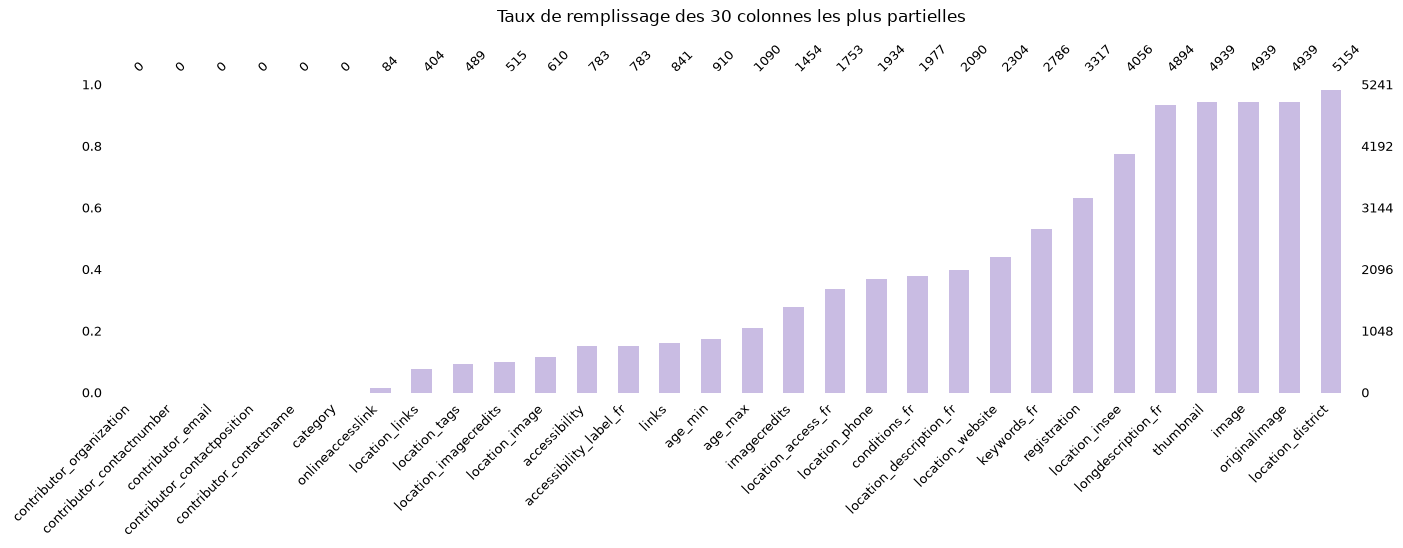

In [94]:
# Valeurs manquantes
manquants = raw.isna().mean().sort_values(ascending=False)
manquants = manquants[manquants > 0]

print(f"{len(manquants)} colonnes sur {raw.shape[1]} comportent des valeurs manquantes.")
print(f"Taux moyen sur ces colonnes : {manquants.mean():.1%}, maximum : {manquants.max():.1%}\n")

# Taux de remplissage
ax = msno.bar(raw[manquants.head(30).index.tolist()], color="#C9BCE3", figsize=(16, 4), fontsize=9)
ax.set_title("Taux de remplissage des 30 colonnes les plus partielles", fontsize=12, pad=45)
plt.show()

On peut d'office éliminer les variables jamais renseignées.

### Répartition dans le temps

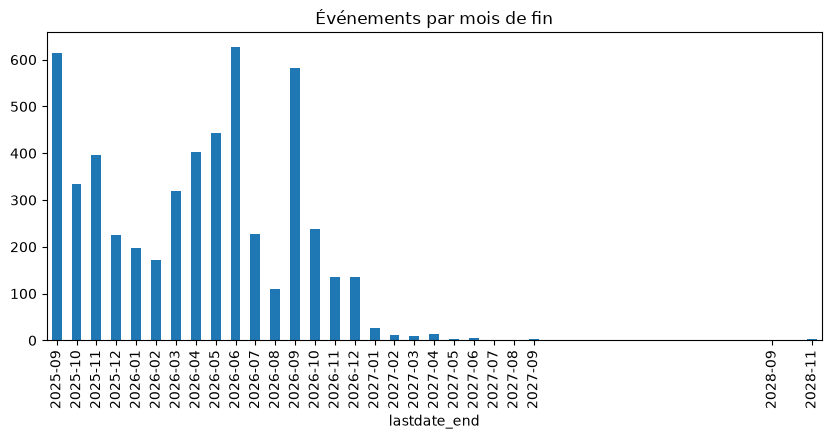

Passés : 4176 | À venir : 1065


In [95]:
# Distribution des événements
start = pd.to_datetime(raw["lastdate_end"], utc=True).dt.tz_localize(None)
start.dt.to_period("M").value_counts().sort_index().plot.bar(figsize=(10, 4), title="Événements par mois de fin")
plt.show()

# Comptage passé / à venir
upcoming = pd.to_datetime(raw["lastdate_end"], utc=True) >= pd.Timestamp.now(tz="UTC")
print(f"Passés : {(~upcoming).sum()} | À venir : {upcoming.sum()}")

Des mois isolés apparaissent en 2028, après vérification ce sont des événements servant de test. On peut donc les ignorer.

#### Source d'événements

In [96]:
# Regroupement par source de l'événement
group("originagenda_title, originagenda_uid", search_filter, limit=30)

,originagenda_title,originagenda_uid,n
0,Bibliothèques de Toulouse,36779486,1285
1,Mes événements France Travail,38495884,1125
2,Conservatoire à rayonnement régional de Toulouse,78623851,260
3,Musée des arts précieux Paul-Dupuy,96583097,224
4,[Archive] Journées européennes du patrimoine 2...,2612063,201
5,Le Cratère,845467,194
6,Journées européennes du patrimoine 2026 - Occi...,3513543,180
7,"SCARE - Syndicat des Cinémas d'Art, de Réperto...",41240026,180
8,Musée des Augustins,20289708,135
9,"Unidivers Oui sortir, vos deux agendas !",14115607,105


La plupart des agendas sont bien culturels (bibliothèques, musées, conservatoire, théâtres, patrimoine…). 

4 sont clairement hors sujet : France Travail (emploi), Challenges Geovelo (défis vélo), Semaine de l'industrie et Renov'energie (rénovation énergétique).

On pourra les exclure par leurs identifiants uid (`originagenda_uid`).

### Anomalies

In [97]:
titles = raw["title_fr"].fillna("")
anomalies = {
    "Titre vide": (titles.str.strip() == "").sum(),
    "Statut annulé": (raw["status"].map(lambda s: json.loads(s)["label"]["fr"]) == "Annulé").sum(),
    "Doublon titre + date + lieu": raw.duplicated(subset=["title_fr", "firstdate_begin", "location_name"]).sum(),
    "Mots-clés répétés": raw["keywords_fr"].map(lambda kw: bool(kw) and len(kw) != len(set(kw))).sum(),
}
pd.Series(anomalies, name="événements").to_frame()

,événements
Titre vide,13
Statut annulé,31
Doublon titre + date + lieu,145
Mots-clés répétés,14


### Longueur des descriptions

Utile pour choisir la taille des chunks par la suite.

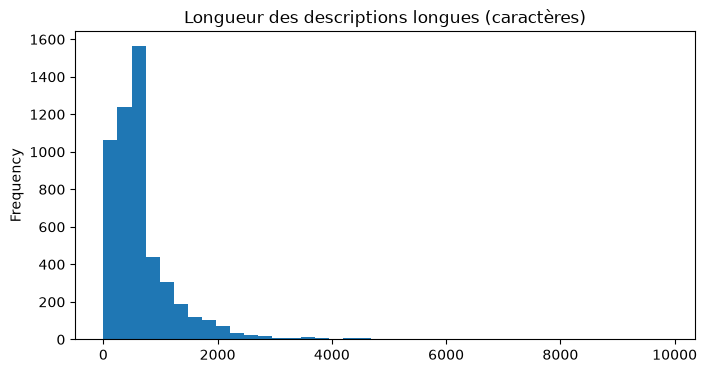

count    5241.0
mean      653.0
std       682.0
min         0.0
25%       298.0
50%       507.0
75%       768.0
max      9866.0
Name: longdescription_fr, dtype: float64

In [98]:
lengths = raw["longdescription_fr"].fillna("").str.len()
lengths.plot.hist(bins=40, figsize=(8, 4), title="Longueur des descriptions longues (caractères)")
plt.show()
lengths.describe().round()

## Règles de nettoyage retenues

| Constat | Traitement |
|---|---|
| Evénements non culturel | Événement supprimé |
| Doublon (titre, date et lieu) | Doublon supprimé |
| Evénements « test » (2028) | Événement supprimé |
| Statut « Annulé » | Événement supprimé |
| Titre vide | Événement supprimé |
| Valeurs manquantes | Remplacées par `""` |
| Mots-clés répétés | Doublon supprimé |
| HTML dans les descriptions | Balises retirées |
| Statut et mode de participation en JSON | Libellé FR extrait |


#### Colonnes conservées : 
 - uid
 - title_fr
 - description_fr
 - longdescription_fr
 - conditions_fr
 - keywords_fr
 - daterange_fr
 - firstdate_begin
 - lastdate_end
 - location_name
 - location_address
 - location_district
 - attendancemode
 - status
 - originagenda_title
 - canonicalurl

#### Colonnes à faible occurence, potentiellement intéressantes en V2 :
 - accessibility
 - accessibility_label_fr
 - location_phone
 - location_website
 - location_description_fr
 - location_access_fr
 - age_min
 - age_max
 - registration
 - links

#### Colonnes peu intérressantes pour l'objet des travaux :
 - originagenda_uid
 - slug
 - updatedat
 - image
 - imagecredits
 - thumbnail
 - originalimage
 - timings
 - firstdate_end
 - lastdate_begin
 - location_uid
 - location_coordinates
 - location_insee
 - location_postalcode
 - location_city
 - location_department
 - location_region
 - location_countrycode
 - country_fr

#### Colonnes principalement vides 

 - contributor_email
 - contributor_contactnumber
 - contributor_contactname
 - contributor_contactposition
 - contributor_organization
 - category
 - onlineaccesslink
 - location_image
 - location_imagecredits
 - location_links
 - location_tags